<a href="https://colab.research.google.com/github/Abhishekksoni/deep_learning/blob/main/02_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
import sklearn


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [ ]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=1000,
                              noise=0.02,
                              random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    train_size=0.2)
X_train[:5], y_train[:5]

(array([[ 0.3953129 , -0.31115633],
        [ 1.28561809, -0.43817236],
        [ 1.33108831, -0.41488722],
        [ 0.12858244,  1.0158113 ],
        [ 1.42712476, -0.40000339]]),
 array([1, 1, 1, 0, 1]))

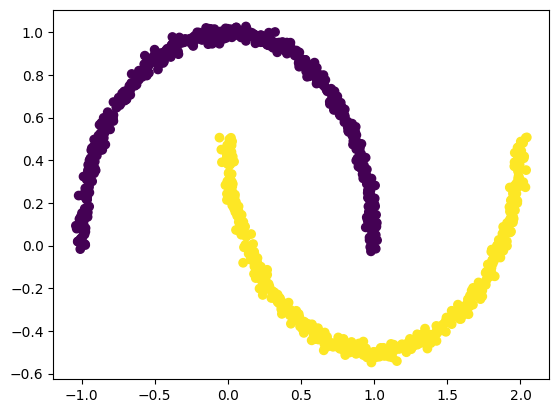

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y)

In [ ]:
X_train.dtype, y_train.dtype

(dtype('float64'), dtype('int64'))

In [ ]:
class MoonModle(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()
  def forward(self,x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_0 = MoonModle().to(device)
model_0

MoonModle(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
X_train = torch.from_numpy(X_train).type(torch.float).to(device)
X_test = torch.from_numpy(X_test).type(torch.float).to(device)
y_test = torch.from_numpy(y_test).type(torch.float).to(device)
y_train = torch.from_numpy(y_train).type(torch.float).to(device)



In [ ]:
y_logits = model_0(X_train).to(device)
y_logits[:5]

tensor([[ 0.0298],
        [-0.0031],
        [-0.0029],
        [ 0.0203],
        [-0.0023]], grad_fn=<SliceBackward0>)

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [ ]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [ ]:
X_train.device

device(type='cpu')

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):

  model_0.train()
  y_logits = model_0(X_train).to(device).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))
  acc = accuracy_fn(y_true=y_train, y_pred = y_pred)

  loss = loss_fn(y_logits, y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_0.eval()

  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    test_loss = loss_fn(test_logits, y_test)

    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss} | Acc: {acc} | Test Loss: {test_loss} | Test Acc: {test_acc}")


Epoch: 0 | Loss: 0.6958557367324829 | Acc: 36.0 | Test Loss: 0.6939939856529236 | Test Acc: 49.875
Epoch: 100 | Loss: 0.3373369574546814 | Acc: 85.5 | Test Loss: 0.38351204991340637 | Test Acc: 79.5
Epoch: 200 | Loss: 0.21697410941123962 | Acc: 88.5 | Test Loss: 0.24910381436347961 | Test Acc: 88.25
Epoch: 300 | Loss: 0.17356906831264496 | Acc: 92.0 | Test Loss: 0.19683349132537842 | Test Acc: 91.25
Epoch: 400 | Loss: 0.14020472764968872 | Acc: 93.5 | Test Loss: 0.15996740758419037 | Test Acc: 93.0
Epoch: 500 | Loss: 0.10389716178178787 | Acc: 96.5 | Test Loss: 0.11965333670377731 | Test Acc: 95.125
Epoch: 600 | Loss: 0.07053788006305695 | Acc: 97.0 | Test Loss: 0.08184488117694855 | Test Acc: 98.0
Epoch: 700 | Loss: 0.04667869955301285 | Acc: 99.0 | Test Loss: 0.05425103008747101 | Test Acc: 99.375
Epoch: 800 | Loss: 0.03217323124408722 | Acc: 100.0 | Test Loss: 0.03737545385956764 | Test Acc: 100.0
Epoch: 900 | Loss: 0.023406580090522766 | Acc: 100.0 | Test Loss: 0.02715245634317398 

In [ ]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


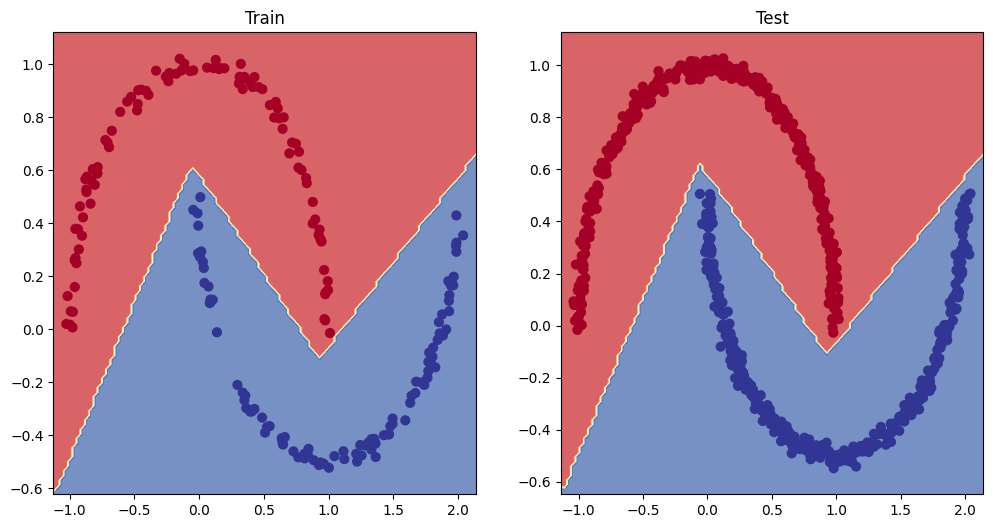

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

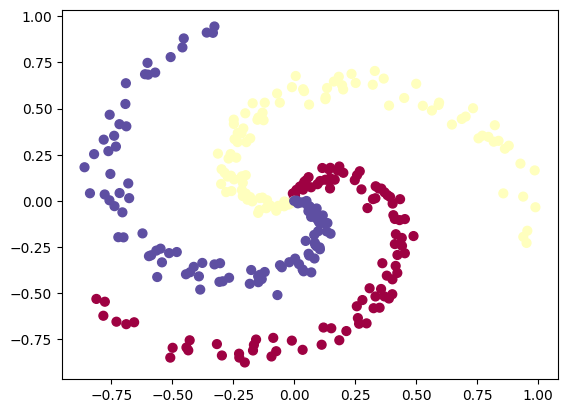

In [ ]:
import numpy as np
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [ ]:
X[:5], y[:5]

(array([[ 0.        ,  0.        ],
        [-0.00176064,  0.00994638],
        [ 0.00038927,  0.02019827],
        [ 0.00359998,  0.03008843],
        [-0.0055227 ,  0.04002482]]),
 array([0, 0, 0, 0, 0], dtype=uint8))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    train_size =0.2)
X_train[:5], y_train[:5]


(array([[-0.50646513,  0.77915237],
        [ 0.40376835, -0.01482469],
        [ 0.40235115, -0.50599416],
        [-0.00807997, -0.00606172],
        [-0.42659234, -0.38667268]]),
 array([2, 0, 0, 1, 2], dtype=uint8))

In [ ]:
X_train = torch.from_numpy(X_train).type(torch.float)
X_test = torch.from_numpy(X_test).type(torch.float)
y_train = torch.from_numpy(y_train).type(torch.float)
y_test = torch.from_numpy(y_test).type(torch.float)

In [ ]:
X_train[:5], y_train[:5]

(tensor([[-0.5065,  0.7792],
         [ 0.4038, -0.0148],
         [ 0.4024, -0.5060],
         [-0.0081, -0.0061],
         [-0.4266, -0.3867]]),
 tensor([2., 0., 0., 1., 2.]))

In [ ]:
class MultiModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear1 = nn.Linear(in_features=2, out_features=10)
    self.linear2 = nn.Linear(in_features=10, out_features=10)
    self.linear3 = nn.Linear(in_features=10, out_features=3)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.linear3(self.relu(self.linear2(self.relu(self.linear1(x)))))
model_1 = MultiModel().to(device)
model_1

MultiModel(
  (linear1): Linear(in_features=2, out_features=10, bias=True)
  (linear2): Linear(in_features=10, out_features=10, bias=True)
  (linear3): Linear(in_features=10, out_features=3, bias=True)
  (relu): ReLU()
)

In [ ]:
model_1

MultiModel(
  (linear1): Linear(in_features=2, out_features=10, bias=True)
  (linear2): Linear(in_features=10, out_features=10, bias=True)
  (linear3): Linear(in_features=10, out_features=3, bias=True)
  (relu): ReLU()
)

In [ ]:
# Let's calculate the accuracy for when we fit our model
!pip -q install torchmetrics # colab doesn't come with torchmetrics
from torchmetrics import Accuracy
acc_fn = Accuracy(task="multiclass", num_classes=3).to(device) # send accuracy function to device
acc_fn

MulticlassAccuracy()

In [ ]:
X_train.dtype, y_train.dtype

(torch.float32, torch.float32)

In [ ]:
y_logits = model_1(X_train)
y_logits[:5]

tensor([[-0.2231, -0.0458,  0.2519],
        [-0.2156, -0.0549,  0.2423],
        [-0.1998, -0.0513,  0.2273],
        [-0.2220, -0.0610,  0.2357],
        [-0.2218, -0.0625,  0.2303]], grad_fn=<SliceBackward0>)

In [ ]:
y_pred = torch.softmax(y_logits,dim=1)
y_pred[:5]

tensor([[0.2630, 0.3140, 0.4229],
        [0.2663, 0.3127, 0.4210],
        [0.2708, 0.3141, 0.4151],
        [0.2663, 0.3128, 0.4209],
        [0.2671, 0.3132, 0.4197]], grad_fn=<SliceBackward0>)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_1.parameters(),lr=0.02)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

for epoch in range(epochs):
  model_1.train()

  y_logits = model_1(X_train).squeeze()
  y_pred = torch.softmax(y_logits, dim=1)
  acc = accuracy_fn(y_true=y_train, y_pred=torch.argmax(y_pred, dim=1))

  loss = loss_fn(y_logits, y_train.long())

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_1.eval()

  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.softmax(test_logits, dim=1)

    test_acc = accuracy_fn(y_true=y_test, y_pred=torch.argmax(test_pred, dim=1))

    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss} | Acc: {acc} | Test Loss: {test_loss} | Test Acc: {test_acc}")

Epoch: 0 | Loss: 1.116912841796875 | Acc: 36.666666666666664 | Test Loss: 0.020810460671782494 | Test Acc: 32.5
Epoch: 100 | Loss: 0.30343812704086304 | Acc: 93.33333333333333 | Test Loss: 0.020810460671782494 | Test Acc: 88.75
Epoch: 200 | Loss: 0.11655879765748978 | Acc: 96.66666666666667 | Test Loss: 0.020810460671782494 | Test Acc: 92.08333333333333
Epoch: 300 | Loss: 0.07240943610668182 | Acc: 98.33333333333333 | Test Loss: 0.020810460671782494 | Test Acc: 92.5
Epoch: 400 | Loss: 0.044096995145082474 | Acc: 98.33333333333333 | Test Loss: 0.020810460671782494 | Test Acc: 92.08333333333333
Epoch: 500 | Loss: 0.031815048307180405 | Acc: 100.0 | Test Loss: 0.020810460671782494 | Test Acc: 92.91666666666667
Epoch: 600 | Loss: 0.023999014869332314 | Acc: 100.0 | Test Loss: 0.020810460671782494 | Test Acc: 92.91666666666667
Epoch: 700 | Loss: 0.01899978518486023 | Acc: 100.0 | Test Loss: 0.020810460671782494 | Test Acc: 93.75
Epoch: 800 | Loss: 0.015346734784543514 | Acc: 100.0 | Test Lo

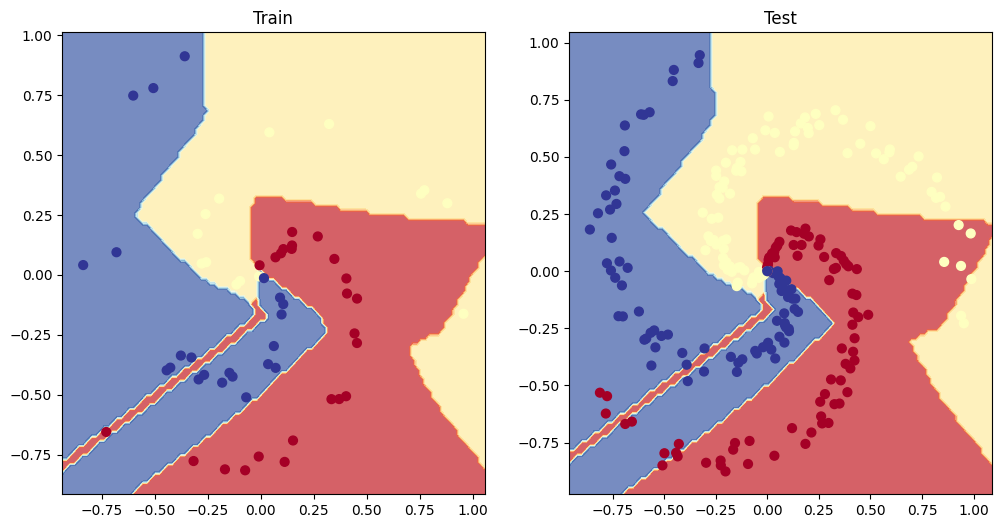

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)